## 1. Daten importieren und Zusammenführen der beiden Datensätze

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

# Datensätze laden
df_meta = pd.read_csv("Daten/db_metadata.csv")
df_measure = pd.read_csv("Daten/db_measurements_v210.csv")

# Datensätze zusammenführen
df = pd.merge(df_meta, df_measure, on='building_id', how='inner')

FileNotFoundError: [Errno 2] No such file or directory: 'db_metadata.csv'

## 2. Erste Übersicht der zusammengeführten Daten

In [ ]:
# Datenstruktur analysieren
df.shape

(109033, 74)

Ergebnis: Es gibt 109.033 Zeileneinträge und 74 Spalten

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 109033 entries, 0 to 109032
Data columns (total 74 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   building_id                 109033 non-null  int64  
 1   building_id_inf             109033 non-null  str    
 2   contributor                 109033 non-null  str    
 3   publication                 107378 non-null  str    
 4   region                      109020 non-null  str    
 5   country                     109033 non-null  str    
 6   city                        109020 non-null  str    
 7   lat                         107869 non-null  float64
 8   lon                         107869 non-null  float64
 9   climate                     109033 non-null  str    
 10  building_type               109033 non-null  str    
 11  cooling_type                107507 non-null  str    
 12  year                        109033 non-null  int64  
 13  records                  

- Bei den folgenden Spalten müssen die Datentypen konvertiert werden:
    - Timestamp: str -> datetime 
    - subject_id: str -> int 
    - age: float oder int? -> Entscheidung: nicht konvertieren
    - blind_curtain: float -> int 
    - Fan: float -> int 
    - Window: float -> int 
    - Door: float -> int 
    - heater: float -> int 

In [ ]:
df.head()

,building_id,building_id_inf,contributor,publication,region,country,city,lat,lon,climate,...,t_out,rh_out,t_out_isd,rh_out_isd,set,pmv,ppd,pmv_ce,ppd_ce,t_mot_isd
0,1,no,David Rowe,NaN,oceania,australia,sydney,-33.86882,151.209295,humid subtropical,...,15.86,99.1,16.295833,86.837514,28.1,0.50,10.2,0.38,8.0,17.4
1,1,no,David Rowe,NaN,oceania,australia,sydney,-33.86882,151.209295,humid subtropical,...,15.86,99.1,16.295833,86.837514,27.2,0.40,8.4,0.40,8.4,17.4
2,1,no,David Rowe,NaN,oceania,australia,sydney,-33.86882,151.209295,humid subtropical,...,15.86,99.1,16.295833,86.837514,24.8,-0.07,5.1,-0.07,5.1,17.4
3,1,no,David Rowe,NaN,oceania,australia,sydney,-33.86882,151.209295,humid subtropical,...,15.86,99.1,16.295833,86.837514,25.5,0.31,7.0,0.14,5.4,17.4
4,1,no,David Rowe,NaN,oceania,australia,sydney,-33.86882,151.209295,humid subtropical,...,15.86,99.1,16.295833,86.837514,26.0,0.05,5.0,-0.06,5.1,17.4


In [ ]:
# Spaltennamen anzeigen
df.columns

Index(['building_id', 'building_id_inf', 'contributor', 'publication',
       'region', 'country', 'city', 'lat', 'lon', 'climate', 'building_type',
       'cooling_type', 'year', 'records', 'has_age', 'has_ec', 'has_timestamp',
       'timezone', 'met_source', 'isd_station', 'isd_distance', 'database',
       'quality_assurance', 'index', 'record_id', 'timestamp', 'season',
       'subject_id', 'age', 'gender', 'ht', 'wt', 'ta', 'ta_h', 'ta_m', 'ta_l',
       'top', 'tr', 'tg', 'tg_h', 'tg_m', 'tg_l', 'rh', 'vel', 'vel_h',
       'vel_m', 'vel_l', 'met', 'clo', 'activity_10', 'activity_20',
       'activity_30', 'activity_60', 'thermal_sensation',
       'thermal_acceptability', 'thermal_preference', 'thermal_comfort',
       'air_movement_acceptability', 'air_movement_preference',
       'blind_curtain', 'fan', 'window', 'door', 'heater', 't_out', 'rh_out',
       't_out_isd', 'rh_out_isd', 'set', 'pmv', 'ppd', 'pmv_ce', 'ppd_ce',
       't_mot_isd'],
      dtype='str')

In [ ]:
# Statistische Daten
stats = df.describe()
display(stats)

,building_id,lat,lon,year,records,isd_distance,database,index,record_id,age,...,t_out,rh_out,t_out_isd,rh_out_isd,set,pmv,ppd,pmv_ce,ppd_ce,t_mot_isd
count,109033.000000,107869.000000,107869.000000,109033.000000,109033.000000,66761.000000,109033.000000,109033.000000,109033.000000,48994.000000,...,69307.000000,25524.000000,65834.000000,61174.000000,55113.000000,52114.000000,52114.000000,55369.000000,55369.000000,64505.000000
mean,456.517724,27.519149,18.547012,2002.799033,714.584098,11.273840,1.773978,55093.077032,55094.077032,33.239106,...,19.846301,67.310111,20.215111,68.537951,24.700410,-0.161286,15.631324,-0.118738,17.132789,20.242018
std,256.310688,26.277405,82.109471,9.475535,619.129169,10.287265,0.425953,31849.740073,31849.740073,14.350829,...,10.353298,12.639202,9.340614,16.075476,2.972496,0.699802,14.089070,0.792003,18.143113,9.227086
min,1.000000,-37.813628,-157.858140,1982.000000,1.000000,0.200000,1.000000,0.000000,1.000000,6.000000,...,-28.800000,24.975000,-30.600000,15.667263,8.500000,-2.000000,5.000000,-5.370000,5.000000,-25.300000
25%,188.000000,17.385044,-8.629105,1995.000000,193.000000,5.400000,2.000000,27387.000000,27388.000000,22.000000,...,13.715000,57.050000,14.208333,60.214529,22.800000,-0.620000,6.000000,-0.580000,6.000000,14.500000
50%,592.000000,34.749212,4.835659,2003.000000,518.000000,8.500000,2.000000,55320.000000,55321.000000,30.000000,...,21.400000,69.675000,22.571429,71.941079,24.400000,-0.180000,9.700000,-0.150000,9.500000,22.600000
75%,671.000000,49.006890,78.486671,2011.000000,1097.000000,14.400000,2.000000,82634.000000,82635.000000,45.000000,...,27.544793,76.000000,27.306913,80.181855,26.300000,0.280000,19.400000,0.310000,19.700000,27.200000
max,809.000000,57.708870,153.026034,2021.000000,2242.000000,104.700000,2.100000,110069.000000,110070.000000,95.000000,...,45.050000,100.350000,38.693750,100.000000,39.600000,1.990000,76.700000,4.190000,100.000000,36.800000


In [ ]:
# Anzeigen von Duplikaten
duplicates = df[df.duplicated()]
duplicates

,building_id,building_id_inf,contributor,publication,region,country,city,lat,lon,climate,...,t_out,rh_out,t_out_isd,rh_out_isd,set,pmv,ppd,pmv_ce,ppd_ce,t_mot_isd


Ergebnis: keine Duplikate

In [ ]:
# Ausgeben der Anzahl fehlender Werte
df.isnull().sum()

building_id            0
building_id_inf        0
contributor            0
publication         1655
region                13
                   ...  
pmv                56919
ppd                56919
pmv_ce             53664
ppd_ce             53664
t_mot_isd          44528
Length: 74, dtype: int64

Ergebnis:
- Spalten, die keine fehlenden Werte haben:
    - building_id
    - building_id_inf
    - contributor
    - country
    - climate
    - building_type
    - year
    - records
    - has_age
    - has_ec
    - has_timestamp
    - database
    - quality_assurance
    - index
    - record_id
    - ta
  

In [ ]:
# Entfernen von vollständig leeren Zeilen
df = df.dropna(how='all').reset_index(drop=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 109033 entries, 0 to 109032
Data columns (total 74 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   building_id                 109033 non-null  int64  
 1   building_id_inf             109033 non-null  str    
 2   contributor                 109033 non-null  str    
 3   publication                 107378 non-null  str    
 4   region                      109020 non-null  str    
 5   country                     109033 non-null  str    
 6   city                        109020 non-null  str    
 7   lat                         107869 non-null  float64
 8   lon                         107869 non-null  float64
 9   climate                     109033 non-null  str    
 10  building_type               109033 non-null  str    
 11  cooling_type                107507 non-null  str    
 12  year                        109033 non-null  int64  
 13  records                  

Ergebnis: Es gibt keine vollständig leeren Zeilen

## 3. Bereinigung der Datentypen

In [ ]:
# Spalte "timestamp" von str in datetime umwandeln
df["timestamp"] = pd.to_datetime(df["timestamp"], format='%Y-%m-%dT%H:%M:%SZ', errors="coerce") 

# Spalte "subject_id" von str in int umwandeln
df["subject_id"] = pd.to_numeric(df["subject_id"], errors="coerce").astype('Int64') 

# Spalte "blind_curtain" von float in int umwandeln
df["blind_curtain"] = df["blind_curtain"].astype('Int64')

# Spalte "fan" von float in int umwandeln
df["fan"] = df["fan"].astype('Int64')

# Spalte "window" von float in int umwandeln
df["window"] = df["window"].astype('Int64')

# Spalte "door" von float in int umwandeln
df["door"] = df["door"].astype('Int64')

# Spalte "heater" von float in int umwandeln
df["heater"] = df["heater"].astype('Int64')

## 4. Umbenennung von Spalten 

In [ ]:
# Für besseres Verständnis Umbenennen von bestimmten Spalten
df = df.rename(columns={"lat": "latitude", "lon": "longitude", "has_ec": "has_environmental_controls", "met_source": "source_meteorological_data", "ht": "height", "wt": "weight", "ta": "air_temperature", "ta_h": "air_temperature_1.1", "ta_m": "air_temperature_0.6", "ta_l": "air_temperature_0.1", "top": "operative_temperature", "tr": "radiant_temperature", "tg": "globe_temperature", "tg_h": "globe_temperature_1.1", "tg_m": "globe_temperature_0.6", "tg_l": "globe_temperature_0.1", "rh": "relative_humidity", "vel": "air_speed", "vel_h": "air_speed_1.1", "vel_m": "air_speed_0.6", "vel_l": "air_speed_0.1", "vel_r": "relative_air_speed", "met": "metabolic_rate", "clo": "clothing_ensemble_insulation", "clo_d": "dynamic_clothing", "pmv": "predicted_mean_vote", "pmv_ce": "calculated_predicted_mean_vote", "ppd": "predicted_percentage_dissatisfied", "ppd_ce": "calculated_predicted_percentage_dissatisfied", "set": "standard_effective_temperature", "t_out": "outdoor_air_temperature", "rh_out": "outdoor_relative_humidity", "t_out_isd": "average_daily_outdoor_temperature", "rh_out_isd": "average_daily_outdoor_humidity", "t_mot_isd": "7_day_mean_outdoor_temperature"})

## 5. Übersichten zu Verteilung der Daten

Nach Land

In [ ]:
# Anzahl Einträge je Land
country_anzahl = df["country"].value_counts()
print(country_anzahl)

country
uk             25447
india          18714
usa            15021
australia       8002
brazil          7389
china           6246
pakistan        4149
canada          2728
malaysia        2299
iran            1971
greece          1940
tunisia         1581
portugal        1558
italy           1554
mexico          1417
japan           1275
thailand        1160
singapore       1090
germany         1049
indonesia        996
sweden           939
south korea      530
france           480
nigeria          468
slovakia         457
philippines      277
denmark          170
belgium           85
cyprus            41
Name: count, dtype: int64


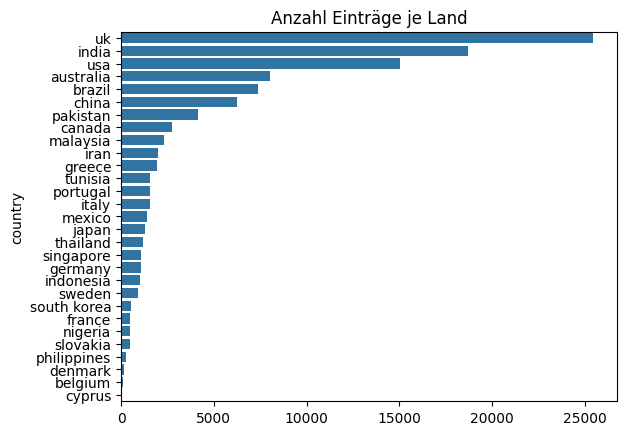

In [ ]:
# Balkendiagramm für Verteilung der Länder
sns.barplot(x=country_anzahl.values, y=country_anzahl.index)
plt.title("Anzahl Einträge je Land")
plt.show()

Nach Stadt

In [ ]:
# Anzahl Einträge je Stadt
city_anzahl = df["city"].value_counts()
print(city_anzahl)

city
midland          19934
florianopolis     5264
san francisco     4822
chennai           4379
honolulu          3544
                 ...  
beverly hills       27
recife              27
brasilia            24
kinarut             10
kuching              9
Name: count, Length: 103, dtype: int64


Nach Region

In [ ]:
# Anzahl Einträge je Region
region_anzahl = df["region"].value_counts()
print(region_anzahl)

region
asia        38735
europe      33679
americas    23011
oceania     11546
africa       2049
Name: count, dtype: int64


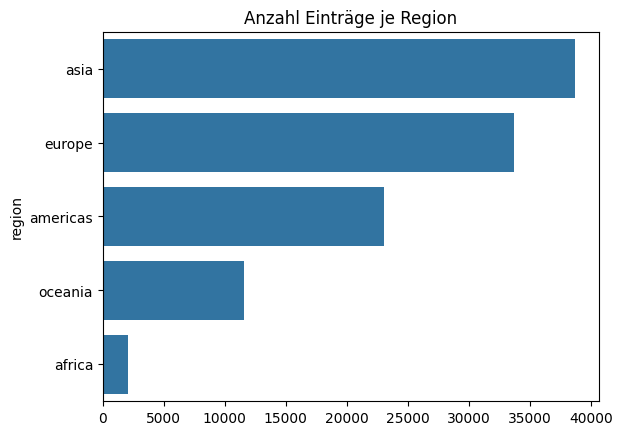

In [ ]:
# Balkendiagramm für Verteilung der Regionen
sns.barplot(x=region_anzahl.values, y=region_anzahl.index)
plt.title("Anzahl Einträge je Region")
plt.show()

Nach Gebäudeart

In [ ]:
# Anzahl Einträge je Gebäudeart
building_type_anzahl = df["building_type"].value_counts()
print(building_type_anzahl)

building_type
office                 77260
multifamily housing    13984
classroom              11704
others                  5264
senior center            821
Name: count, dtype: int64


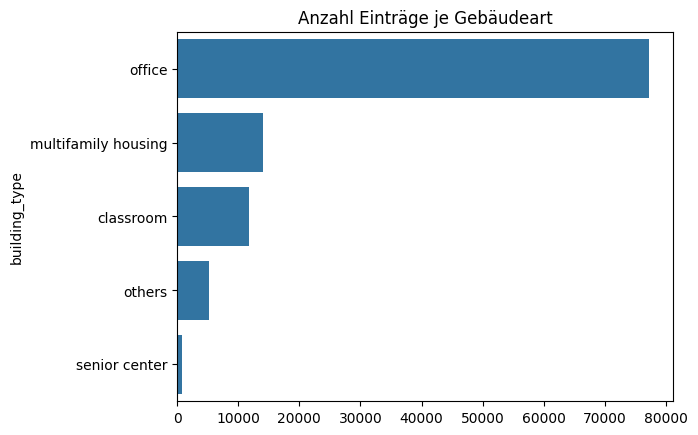

In [ ]:
# Balkendiagramm für Verteilung der Gebäudearten
sns.barplot(x=building_type_anzahl.values, y=building_type_anzahl.index)
plt.title("Anzahl Einträge je Gebäudeart")
plt.show()

Nach Cooling Strategy

In [ ]:
# Anzahl Einträge je Cooling Strategy
cooling_type_anzahl = df["cooling_type"].value_counts()
print(cooling_type_anzahl)

cooling_type
naturally ventilated    46430
air conditioned         32588
mixed mode              28489
Name: count, dtype: int64


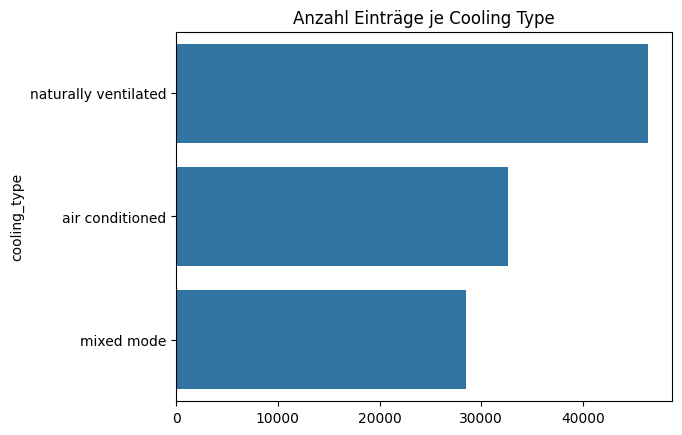

In [ ]:
# Balkendiagramm für Verteilung der Cooling Strategy
sns.barplot(x=cooling_type_anzahl.values, y=cooling_type_anzahl.index)
plt.title("Anzahl Einträge je Cooling Type")
plt.show()

Nach Season

In [ ]:
# Anzahl Einträge je Season
season_anzahl = df["season"].value_counts()
print(season_anzahl)

season
summer      50278
winter      40058
hot/wet      8666
cool/dry     8062
autumn        967
spring        917
Name: count, dtype: int64


-> Autumn und Spring gibt es nur in der Database 2.1

-> die anderen seasons gibt es in allen 3 Databases

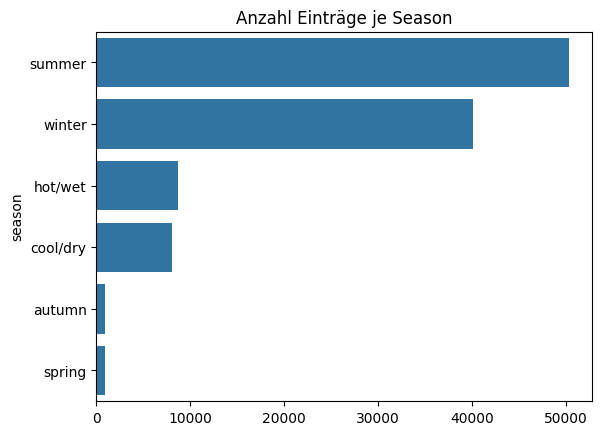

In [ ]:
# Balkendiagramm für Verteilung der Seasons
sns.barplot(x=season_anzahl.values, y=season_anzahl.index)
plt.title("Anzahl Einträge je Season")
plt.show()

## 6. Überprüfung, welche Muster es bei fehlenden Werten gibt

<Axes: >

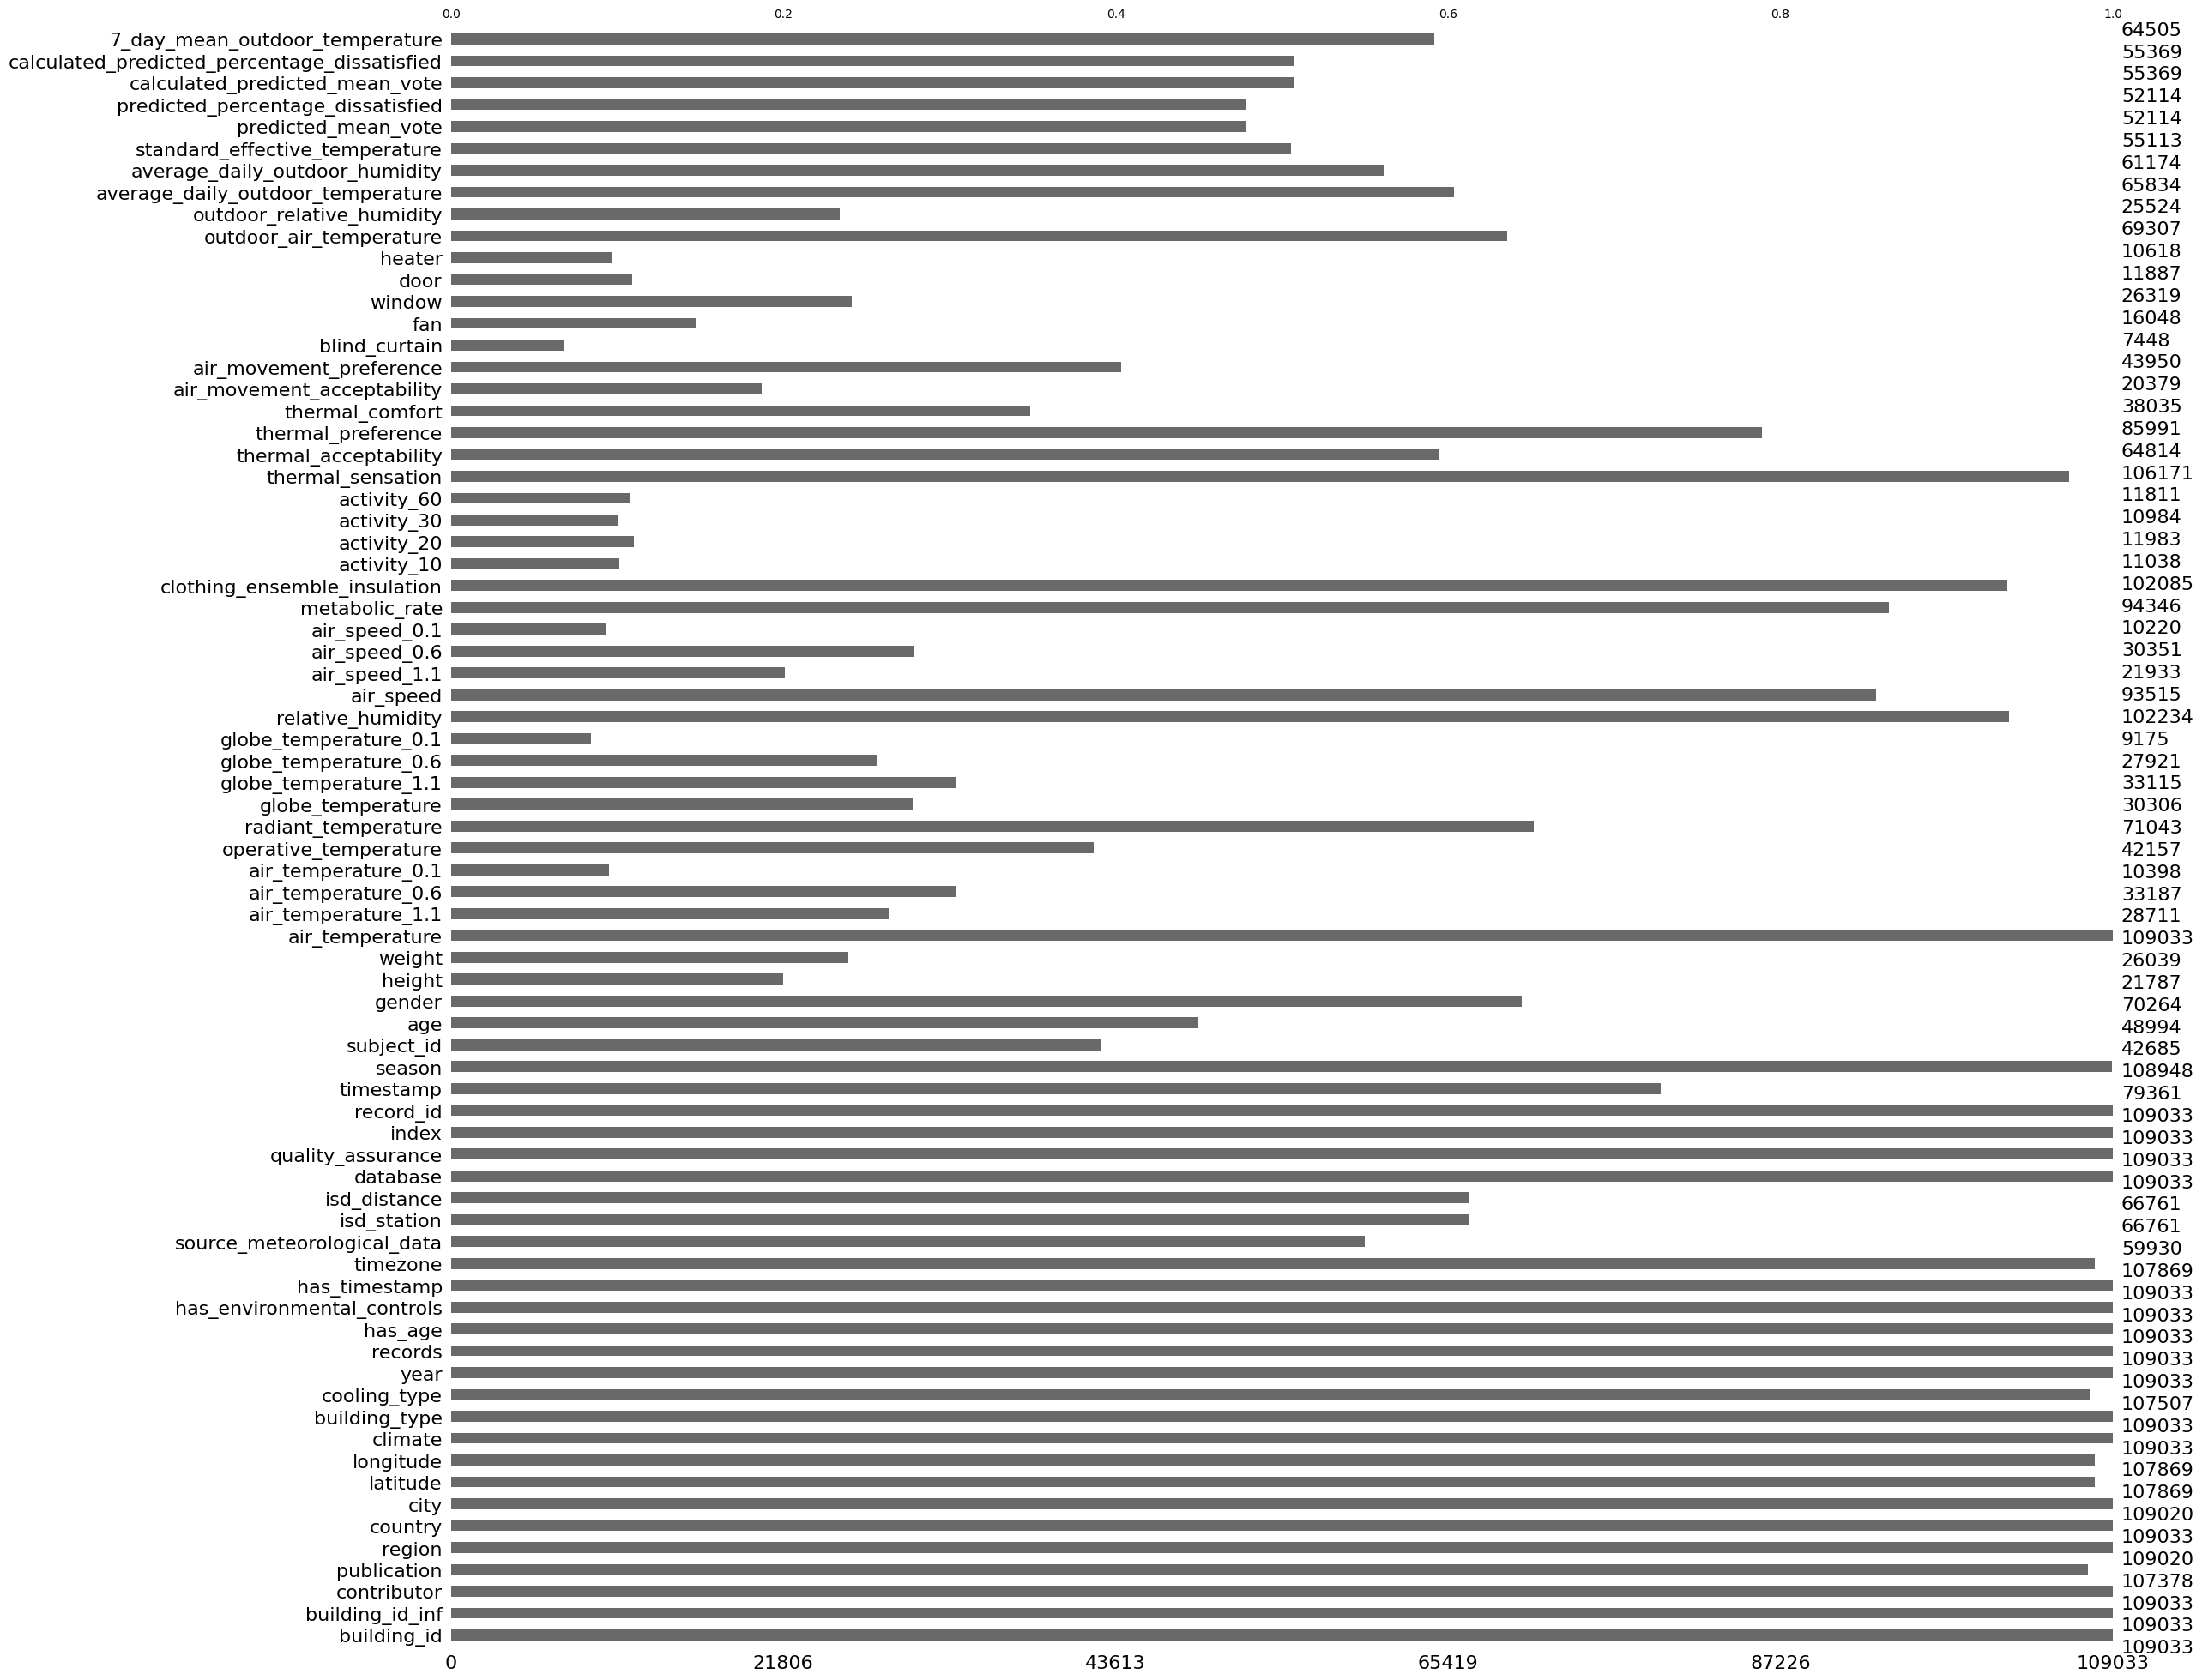

In [ ]:
# Bar Chart: Zeigt die Vollständigkeit jeder Spalte
msno.bar(df)

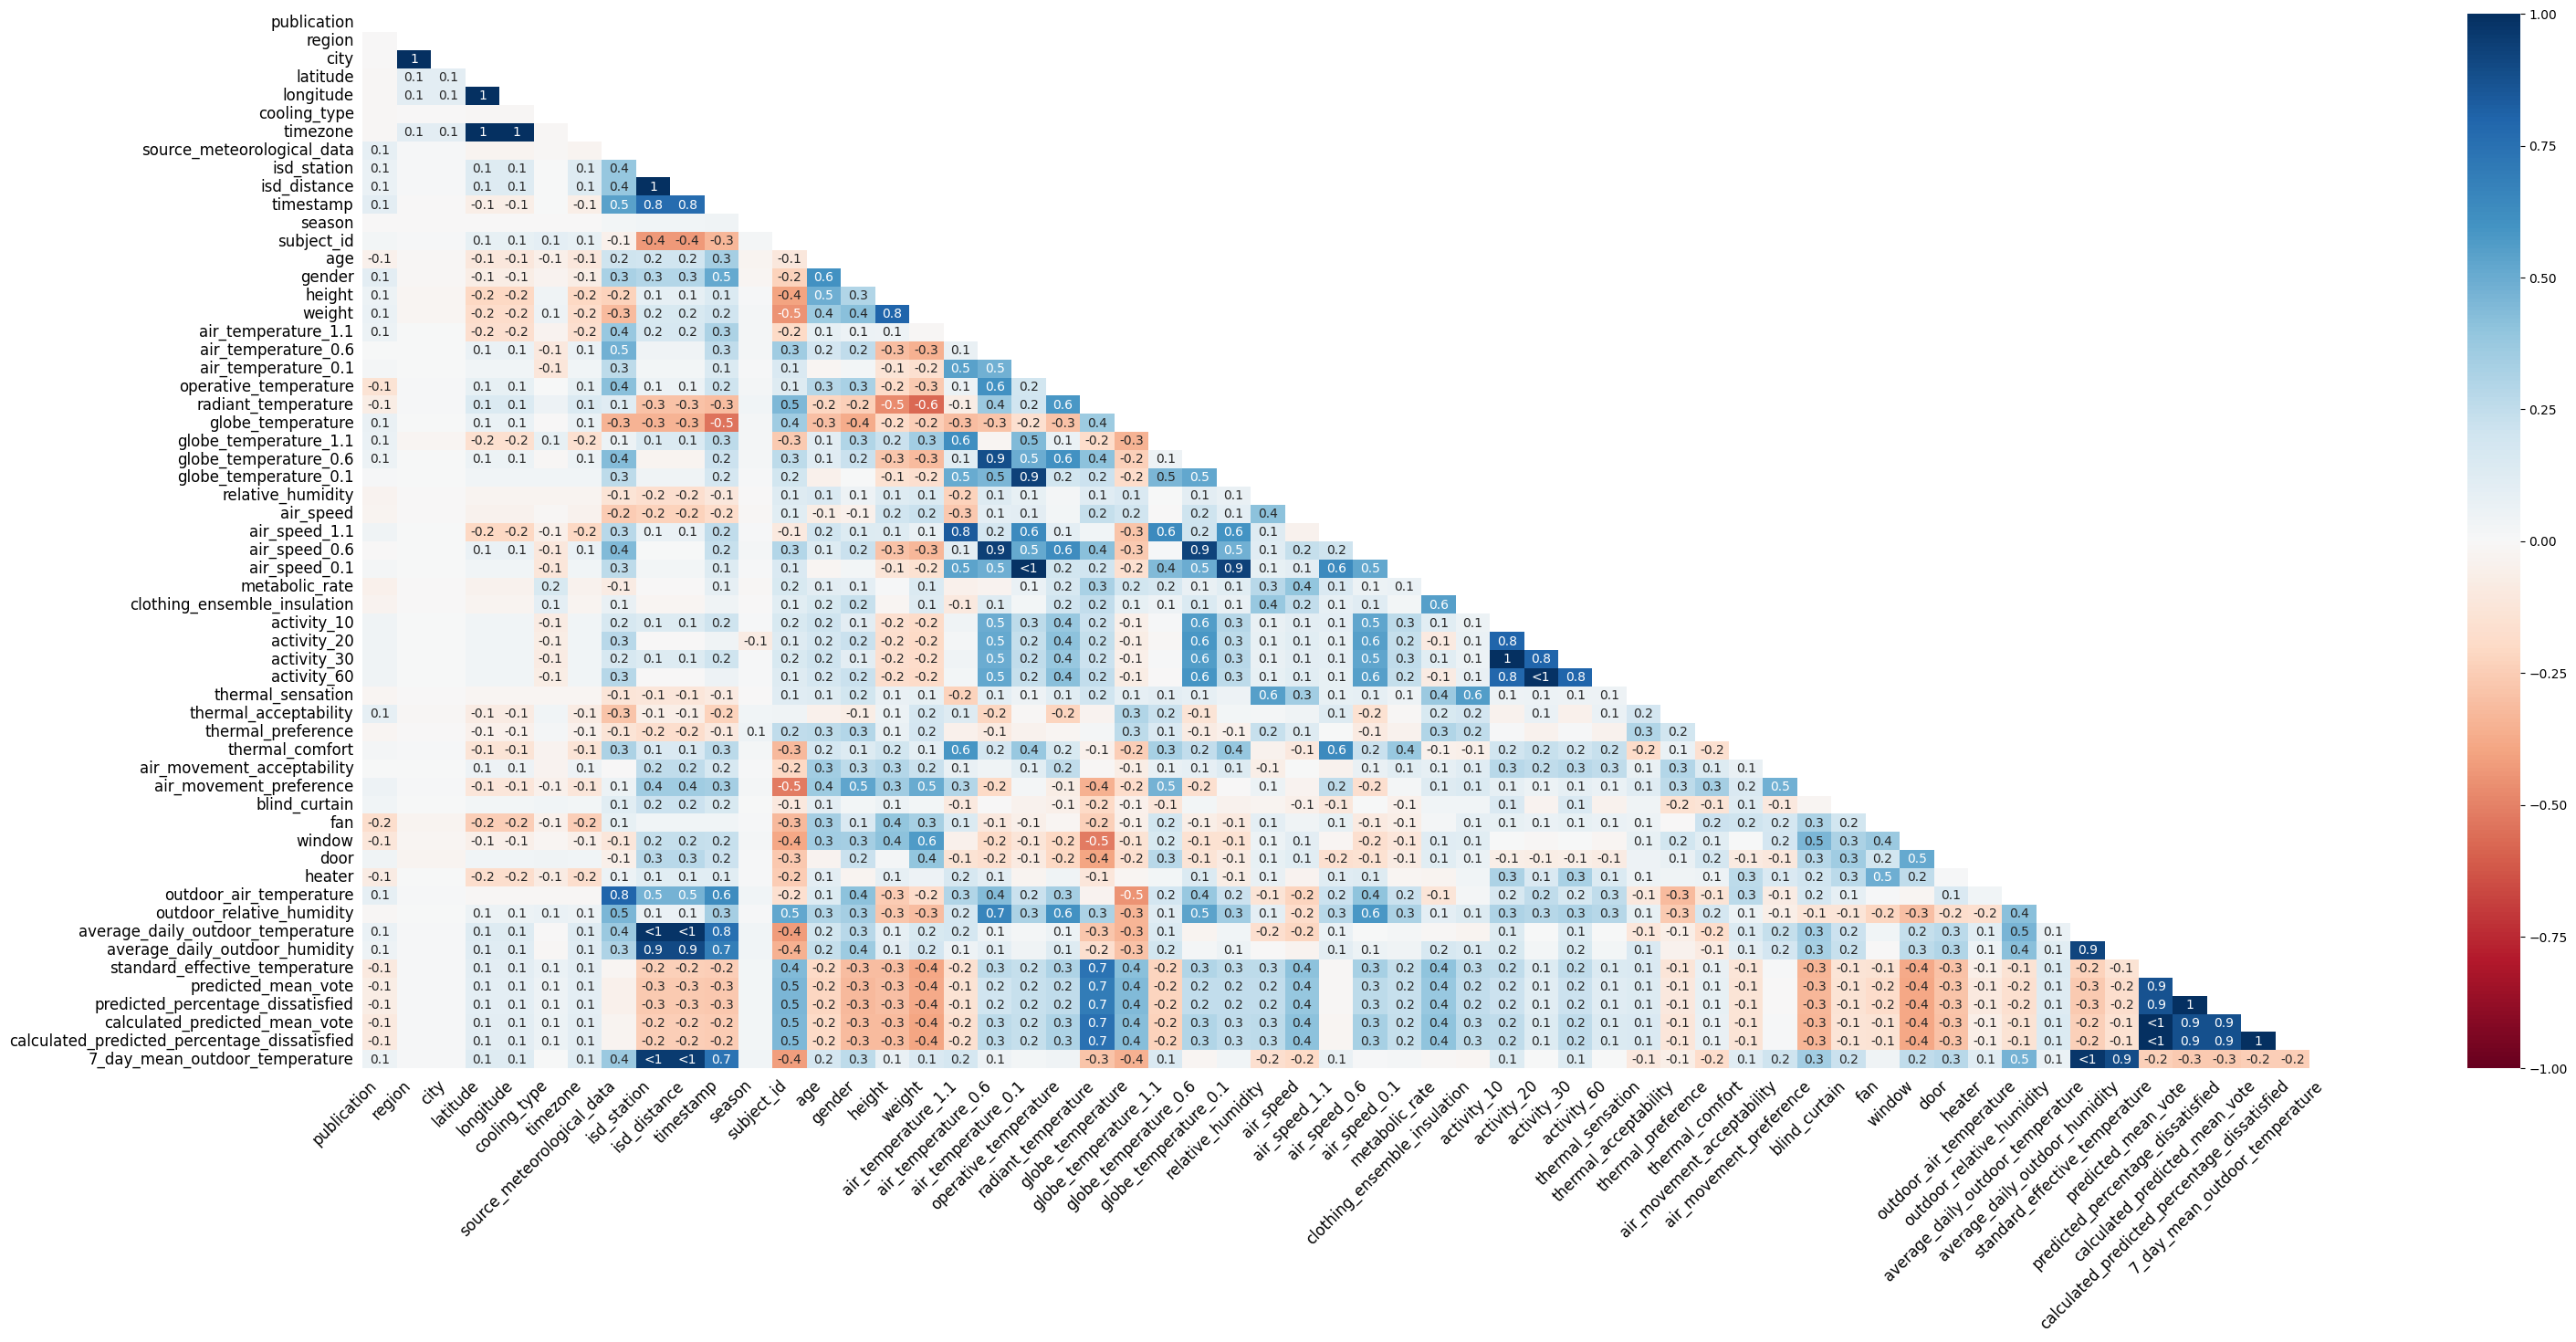

In [ ]:
# Heatmap: Zeigt an, wie stark das Fehlen von Werten zwischen Spalten korreliert
msno.heatmap(df, figsize=(35, 15), fontsize=12)
plt.show()

Untersuchung der fehlenden Werte auf Muster nach Ländern

In [ ]:
# Anteil der fehlenden Werte der Länder prozentual
fehlende_werte_prozent = df.groupby('country').apply(lambda x: x.isna().mean() * 100)
print(fehlende_werte_prozent)

             building_id  building_id_inf  contributor  publication    region  \
country                                                                         
australia            0.0              0.0          0.0     4.873782  0.000000   
belgium              0.0              0.0          0.0     0.000000  0.000000   
brazil               0.0              0.0          0.0     0.000000  0.000000   
canada               0.0              0.0          0.0     0.000000  0.000000   
china                0.0              0.0          0.0     0.000000  0.000000   
cyprus               0.0              0.0          0.0     0.000000  0.000000   
denmark              0.0              0.0          0.0     0.000000  0.000000   
france               0.0              0.0          0.0     0.000000  0.000000   
germany              0.0              0.0          0.0     0.000000  0.000000   
greece               0.0              0.0          0.0     0.000000  0.000000   
india                0.0    

Untersuchung der fehlenden Werte auf Muster nach Regionen prozentual

In [ ]:
# Anteil der fehlenden Werte der Regionen prozentual
fehlende_werte_prozent_region = df.groupby('region').apply(lambda x: x.isna().mean() * 100)
print(fehlende_werte_prozent_region)

          building_id  building_id_inf  contributor  publication  country  \
region                                                                      
africa            0.0              0.0          0.0     0.000000      0.0   
americas          0.0              0.0          0.0     0.369389      0.0   
asia              0.0              0.0          0.0     3.046341      0.0   
europe            0.0              0.0          0.0     0.000000      0.0   
oceania           0.0              0.0          0.0     3.377793      0.0   

          city  latitude  longitude  climate  building_type  ...  \
region                                                       ...   
africa     0.0  0.000000   0.000000      0.0            0.0  ...   
americas   0.0  0.000000   0.000000      0.0            0.0  ...   
asia       0.0  2.971473   2.971473      0.0            0.0  ...   
europe     0.0  0.000000   0.000000      0.0            0.0  ...   
oceania    0.0  0.000000   0.000000      0.0        

## 8. Entfernen der nicht benötigten Spalten

In [ ]:
# Spalten entfernen
df = df.drop(columns=["building_id_inf", "publication", "has_age", "has_environmental_controls", "has_timestamp", "timezone", "source_meteorological_data", "isd_station", "isd_distance", "subject_id", "height", "weight", "average_daily_outdoor_temperature", "average_daily_outdoor_humidity", "7_day_mean_outdoor_temperature"])

## 9. Behandeln der kategorialen Spalten mit fehlenden Werten

In [ ]:
# Spalten mit Kategorie "Unknown" auffüllen
df[["region", "city", "cooling_type", "gender", "thermal_acceptability", "thermal_preference", "air_movement_acceptability", "air_movement_preference"]] = df[["region", "city", "cooling_type", "gender", "thermal_acceptability", "thermal_preference", "air_movement_acceptability", "air_movement_preference"]].fillna("Unknown")

## 10. Runden der thermal_comfort und thermal_sensation Werte

thermal_comfort
5.0    14665
4.0     7532
6.0     6349
3.0     5318
2.0     3567
1.0      604
Name: count, dtype: int64


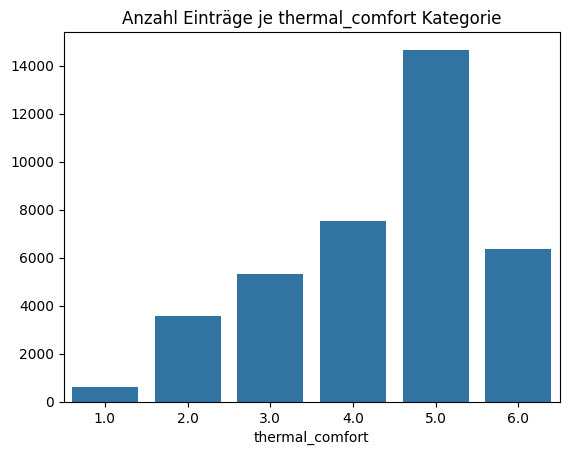

In [ ]:
# Runden der thermal_comfort Werte -> wichtig für Machine Learning
df["thermal_comfort"] = np.floor(df['thermal_comfort'] + 0.5)

# Anzahl Einträge je thermal_comfort Wert
thermal_comfort_anzahl = df["thermal_comfort"].value_counts()
print(thermal_comfort_anzahl)

# Balkendiagramm für Verteilung der thermal_comfort Werte
sns.barplot(x=thermal_comfort_anzahl.index, y=thermal_comfort_anzahl.values)
plt.title("Anzahl Einträge je thermal_comfort Kategorie")
plt.show()

In [ ]:
# Runden der thermal_sensation Werte -> wichtig für Machine Learning
df["thermal_sensation"] = np.floor(df['thermal_sensation'] + 0.5)

# Anzahl Einträge je thermal_comfort Wert
thermal_sensation_anzahl = df["thermal_sensation"].value_counts()
print(thermal_sensation_anzahl)

# Balkendiagramm für Verteilung der thermal_comfort Werte
sns.barplot(x=thermal_sensation_anzahl.index, y=thermal_sensation_anzahl.values)
plt.title("Anzahl Einträge je thermal_comfort Kategorie")
plt.show()

## 11. Zusammenfassen der Klimazonen zu 5 Hauptklimazonen

In [ ]:
# Zusammenfassen der 21 Klimazonen zu 5 Hauptklimazonen
climate_mapping = {
    # A – Tropical
    "tropical": "Tropical",
    "tropical rainforest": "Tropical",
    "wet equatorial": "Tropical",
    "tropical monsoon": "Tropical",
    "tropical savanna": "Tropical",
    "tropical dry savanna": "Tropical",
    "tropical wet savanna": "Tropical",

    # B – Dry
    "hot desert": "Dry",
    "desert (hot arid)": "Dry",
    "hot arid": "Dry",
    "hot semi-arid": "Dry",
    "cold semi-arid": "Dry",
    "semi arid midlatitude": "Dry",
    "semi arid high altitude": "Dry",
    "subtropical hot and dry": "Dry",

    # C – Temperate
    "temperate": "Temperate",
    "temperate oceanic": "Temperate",
    "temperature marine": "Temperate",
    "west coast marine": "Temperate",
    "humid midlatitude": "Temperate",
    "humid subtropical": "Temperate",
    "monsoon-influenced humid subtropical": "Temperate",
    "monsoon-influenced temperate oceanic": "Temperate",
    "mediterranean": "Temperate",
    "hot-summer mediterranean": "Temperate",
    "warm-summer mediterranean": "Temperate",
    "cool-summer mediterranean": "Temperate",
    "subtropical highland": "Temperate",

    # D – Continental
    "continental subarctic": "Continental",
    "warm-summer humid continental": "Continental",
    "monsoon-influenced hot-summer humid continental": "Continental",

    # E – Polar -> keine Polar-Klimata in Datensatz
}

df["climate_zone"] = df["climate"].map(climate_mapping)

In [ ]:
# Überprüfung, ob es Klimazonen ohne Einträge gibt
print(df[df["climate_zone"].isna()]["climate"].unique())

<ArrowStringArray>
[]
Length: 0, dtype: str


Ergebnis: keine Klimazonen ohne Einträge

In [ ]:
# Anzahl der Beobachtungen pro Hauptklimazone
df["climate_zone"].value_counts()

climate_zone
Temperate      63075
Tropical       21974
Dry            16386
Continental     7598
Name: count, dtype: int64

In [ ]:
# Ausgabe des Datensatzes zur Überprüfung
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 109033 entries, 0 to 109032
Data columns (total 60 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   building_id                                   109033 non-null  int64         
 1   contributor                                   109033 non-null  str           
 2   region                                        109033 non-null  str           
 3   country                                       109033 non-null  str           
 4   city                                          109033 non-null  str           
 5   latitude                                      107869 non-null  float64       
 6   longitude                                     107869 non-null  float64       
 7   climate                                       109033 non-null  str           
 8   building_type                                 109033 non-null  st

,building_id,contributor,region,country,city,latitude,longitude,climate,building_type,cooling_type,...,door,heater,outdoor_air_temperature,outdoor_relative_humidity,standard_effective_temperature,predicted_mean_vote,predicted_percentage_dissatisfied,calculated_predicted_mean_vote,calculated_predicted_percentage_dissatisfied,climate_zone
0,1,David Rowe,oceania,australia,sydney,-33.86882,151.209295,humid subtropical,office,mixed mode,...,<NA>,<NA>,15.86,99.1,28.1,0.50,10.2,0.38,8.0,Temperate
1,1,David Rowe,oceania,australia,sydney,-33.86882,151.209295,humid subtropical,office,mixed mode,...,<NA>,<NA>,15.86,99.1,27.2,0.40,8.4,0.40,8.4,Temperate
2,1,David Rowe,oceania,australia,sydney,-33.86882,151.209295,humid subtropical,office,mixed mode,...,<NA>,<NA>,15.86,99.1,24.8,-0.07,5.1,-0.07,5.1,Temperate
3,1,David Rowe,oceania,australia,sydney,-33.86882,151.209295,humid subtropical,office,mixed mode,...,<NA>,<NA>,15.86,99.1,25.5,0.31,7.0,0.14,5.4,Temperate
4,1,David Rowe,oceania,australia,sydney,-33.86882,151.209295,humid subtropical,office,mixed mode,...,<NA>,<NA>,15.86,99.1,26.0,0.05,5.0,-0.06,5.1,Temperate


## 11. Speichern der bereinigten Daten in csv-Datei

In [ ]:
df.to_csv("db_bereinigt_fertig.csv", index=False)